# Persona D EDA


## Structure of the notebook:
- Section 1: Data Loading and Profiling
- Section 2: Data Cleaning
- Section 3: Data Refinement for Business Questions

### Data Columns Used for analysis
- Use dt.day_name() and dt.month on metadata_originalPostingDate to find which posting days and months attract the most views and applications.
    * metadata_totalNumberOfView
    * metadata_totalNumberJobApplication
    * day of week on (metadata_originalPostingDate), 
    * month of year on (metadata_originalPostingDate)
    * <>

- Use str.contains to flag titles with keywords like Senior, Junior, Lead, Specialist, Manager. Compare median views and application counts across these groups.
proposed data column to analyze
    * metadata_totalNumberOfView
    * metadata_totalNumberJobApplication
    * <>

- Which primary_category has the lowest applications-per-vacancy ratio (least competitive)? Visualise as a horizontal bar chart.
proposed data column to analyze
    * <>


## Section 1 Source data loading and profiling


### Sanity Check

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


df = pd.read_csv('data/SGJobData.csv')

# Sanity checks
print(df.shape)          # Expect (~1048585, 20)
print(df.dtypes)
print(df.head(3))


(1048585, 22)
categories                             object
employmentTypes                        object
metadata_expiryDate                    object
metadata_isPostedOnBehalf                bool
metadata_jobPostId                     object
metadata_newPostingDate                object
metadata_originalPostingDate           object
metadata_repostCount                    int64
metadata_totalNumberJobApplication      int64
metadata_totalNumberOfView              int64
minimumYearsExperience                  int64
numberOfVacancies                       int64
occupationId                          float64
positionLevels                         object
postedCompany_name                     object
salary_maximum                          int64
salary_minimum                          int64
salary_type                            object
status_id                               int64
status_jobStatus                       object
title                                  object
average_salary      

### Date columns need explicit parsing — do this early so date arithmetic works later:


In [2]:
df['metadata_originalPostingDate'] = pd.to_datetime(df['metadata_originalPostingDate'])
df['metadata_newPostingDate']       = pd.to_datetime(df['metadata_newPostingDate'])
df['metadata_expiryDate']           = pd.to_datetime(df['metadata_expiryDate'])
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048585 entries, 0 to 1048584
Data columns (total 22 columns):
 #   Column                              Non-Null Count    Dtype         
---  ------                              --------------    -----         
 0   categories                          1044597 non-null  object        
 1   employmentTypes                     1044597 non-null  object        
 2   metadata_expiryDate                 1044597 non-null  datetime64[ns]
 3   metadata_isPostedOnBehalf           1048585 non-null  bool          
 4   metadata_jobPostId                  1044597 non-null  object        
 5   metadata_newPostingDate             1044597 non-null  datetime64[ns]
 6   metadata_originalPostingDate        1044597 non-null  datetime64[ns]
 7   metadata_repostCount                1048585 non-null  int64         
 8   metadata_totalNumberJobApplication  1048585 non-null  int64         
 9   metadata_totalNumberOfView          1048585 non-null  int64         

### Initial Profiling

In [3]:
# initial profiling

# Shape, types, missing values at a glance
print(f"Rows: {df.shape[0]:,}  Columns: {df.shape[1]}")
print("\nNull counts:\n", df.isnull().sum().sort_values(ascending=False).head(10))
print("\nBasic stats:\n", df[['salary_minimum','salary_maximum','average_salary',
                               'minimumYearsExperience','numberOfVacancies']].describe())

Rows: 1,048,585  Columns: 22

Null counts:
 occupationId                    1048585
categories                         3988
metadata_expiryDate                3988
title                              3988
metadata_jobPostId                 3988
metadata_newPostingDate            3988
metadata_originalPostingDate       3988
status_jobStatus                   3988
salary_type                        3988
employmentTypes                    3988
dtype: int64

Basic stats:
        salary_minimum  salary_maximum  average_salary  minimumYearsExperience  \
count    1.048585e+06    1.048585e+06    1.048585e+06            1.048585e+06   
mean     3.815312e+03    5.723578e+03    4.769445e+03            2.779573e+00   
std      3.172182e+03    5.018387e+04    2.547809e+04            2.537049e+00   
min      0.000000e+00    0.000000e+00    0.000000e+00            0.000000e+00   
25%      2.500000e+03    3.300000e+03    2.900000e+03            1.000000e+00   
50%      3.000000e+03    4.500000e+03    3

#### Known data-quality landmines (read this!)
Real datasets are dirty. Decide your handling and state it in your presentation.

- Salary outliers. salary_maximum goes up to $25,330,000/month. These are data-entry errors. Decide your cap (e.g. exclude rows where average_salary > 50_000, or clip at the 99th percentile using np.percentile).
- Recruitment agencies dominate. The top "companies" are agencies, not employers. If your question is "who is hiring?", agency-posted jobs distort the answer. - - Use metadata_isPostedOnBehalf and string filtering on postedCompany_name.
categories is a JSON string, not a list. A job can have 1–N categories. You will need str.extract, str.findall, or ast.literal_eval to parse it.
- Re-posts inflate row counts. A single role re-posted 5 times shows up as 5 rows. Use drop_duplicates(subset='metadata_jobPostId', keep='first') when counting unique roles.
- salary_minimum = 1 appears frequently — that is a placeholder, not a real salary. Filter it out with df[df['salary_minimum'] > 100].
Mixed nulls. Columns like positionLevels, employmentTypes, and salary_type contain None as a string, actual NaN, and legitimate blanks. Use .replace('None', np.nan) before .isnull() checks.
- Date coverage is uneven at the start and end of the range. Trim to whole months when computing trends.


#### visualize the null values heatmap to understand the missing data pattern

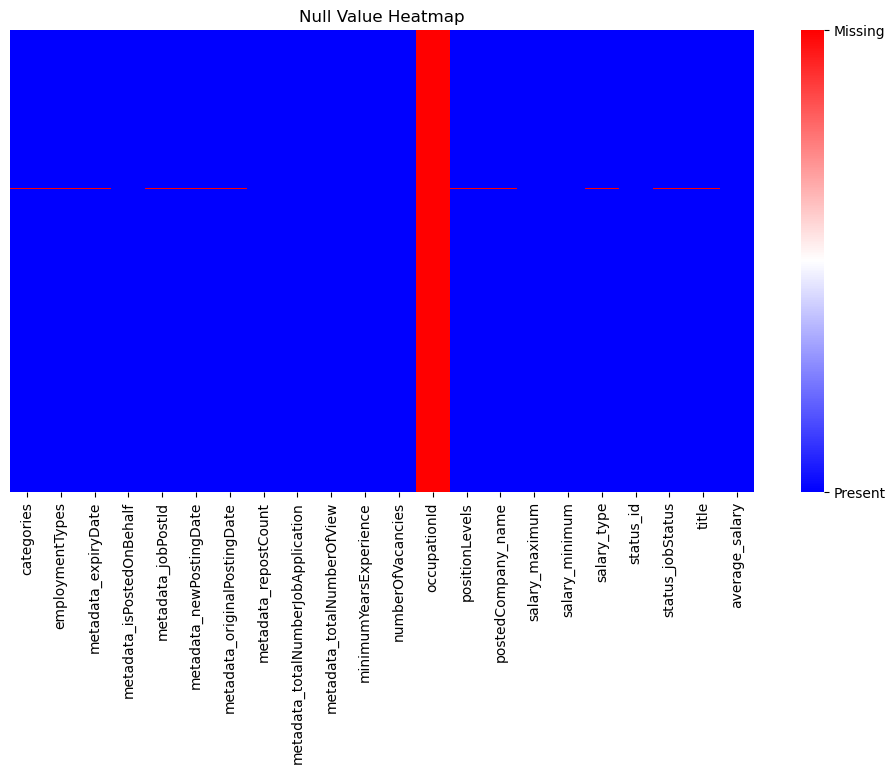

In [4]:
# visualize the null values
plt.figure(figsize=(12, 6))
ax = sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='bwr', cbar_kws={'ticks': [0, 1]})
ax.collections[0].colorbar.set_ticklabels(['Present', 'Missing'])
plt.title('Null Value Heatmap')
plt.show()  

#### null rows and columns

In [5]:
# null columns count
df.isnull().sum()

categories                               3988
employmentTypes                          3988
metadata_expiryDate                      3988
metadata_isPostedOnBehalf                   0
metadata_jobPostId                       3988
metadata_newPostingDate                  3988
metadata_originalPostingDate             3988
metadata_repostCount                        0
metadata_totalNumberJobApplication          0
metadata_totalNumberOfView                  0
minimumYearsExperience                      0
numberOfVacancies                           0
occupationId                          1048585
positionLevels                           3988
postedCompany_name                       3988
salary_maximum                              0
salary_minimum                              0
salary_type                              3988
status_id                                   0
status_jobStatus                         3988
title                                    3988
average_salary                    

In [6]:
# what rows are null, and how many columns are null? 
# df.isna().sum(axis=1).sort_values(ascending=False).groupby().agg('count')
df.isna().sum(axis=1).value_counts()


1     1044597
12       3988
Name: count, dtype: int64

In [7]:
# 1. Identify the rows that have exactly 12 null values
mask = df.isna().sum(axis=1) == 12
df_3988 = df[mask]

# 2. Check which columns in those specific rows are null
null_columns = df_3988.isna().sum().sort_values(ascending=False)

# 3. Filter to only show the columns that actually have nulls
print(null_columns[null_columns > 0])

categories                      3988
metadata_expiryDate             3988
title                           3988
metadata_jobPostId              3988
metadata_newPostingDate         3988
metadata_originalPostingDate    3988
status_jobStatus                3988
salary_type                     3988
employmentTypes                 3988
occupationId                    3988
positionLevels                  3988
postedCompany_name              3988
dtype: int64


#### checking outlier in salary.

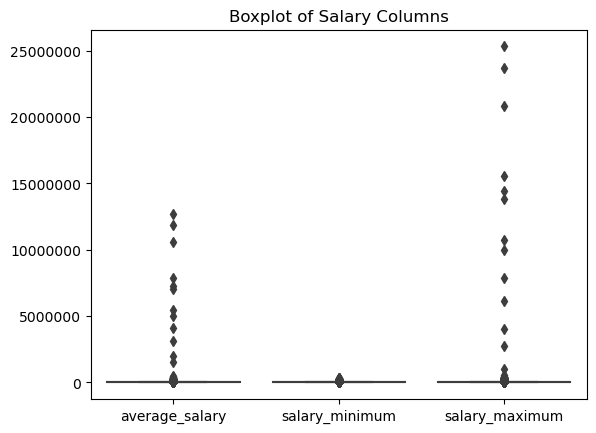

percentile in 25, 50, 75, 90, 95, 99
average salary: [ 2900.   3800.   5500.   8250.  10499.5 16666.5]
salary minimum: [ 2500.  3000.  4500.  6500.  8000. 13000.]
salary maximum: [ 3300.  4500.  6500. 10000. 12000. 20000.]


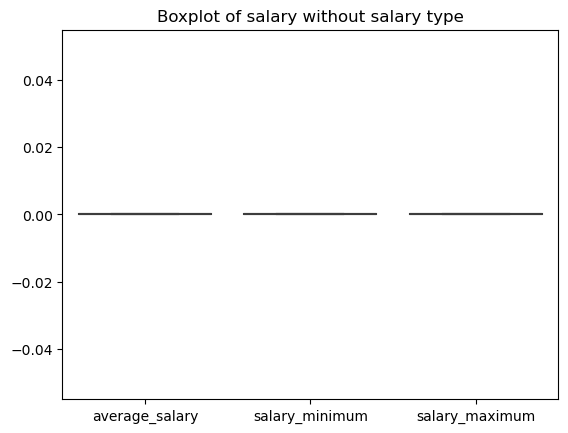

In [8]:
sns.boxplot(df[['average_salary', 'salary_minimum', 'salary_maximum']])
plt.title('Boxplot of Salary Columns')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

print ('percentile in 25, 50, 75, 90, 95, 99')
print (f'average salary: {np.percentile(df["average_salary"], [25, 50, 75, 90, 95, 99])}')
print (f'salary minimum: {np.percentile(df["salary_minimum"], [25, 50, 75, 90, 95, 99])}')
print (f'salary maximum: {np.percentile(df["salary_maximum"], [25, 50, 75, 90, 95, 99])}')


df_null_salary_type = df[df['salary_type'].isna()]

sns.boxplot(df_null_salary_type[['average_salary', 'salary_minimum', 'salary_maximum']])
plt.title('Boxplot of salary without salary type')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [9]:
df_null_salary_type

,categories,employmentTypes,metadata_expiryDate,metadata_isPostedOnBehalf,metadata_jobPostId,metadata_newPostingDate,metadata_originalPostingDate,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,...,occupationId,positionLevels,postedCompany_name,salary_maximum,salary_minimum,salary_type,status_id,status_jobStatus,title,average_salary
197478,NaN,NaN,NaT,False,NaN,NaT,NaT,0,0,0,...,NaN,NaN,NaN,0,0,NaN,0,NaN,NaN,0.0
197480,NaN,NaN,NaT,False,NaN,NaT,NaT,0,0,0,...,NaN,NaN,NaN,0,0,NaN,0,NaN,NaN,0.0
197485,NaN,NaN,NaT,False,NaN,NaT,NaT,0,0,0,...,NaN,NaN,NaN,0,0,NaN,0,NaN,NaN,0.0
197488,NaN,NaN,NaT,False,NaN,NaT,NaT,0,0,0,...,NaN,NaN,NaN,0,0,NaN,0,NaN,NaN,0.0
197502,NaN,NaN,NaT,False,NaN,NaT,NaT,0,0,0,...,NaN,NaN,NaN,0,0,NaN,0,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606668,NaN,NaN,NaT,False,NaN,NaT,NaT,0,0,0,...,NaN,NaN,NaN,0,0,NaN,0,NaN,NaN,0.0
606670,NaN,NaN,NaT,False,NaN,NaT,NaT,0,0,0,...,NaN,NaN,NaN,0,0,NaN,0,NaN,NaN,0.0
606678,NaN,NaN,NaT,False,NaN,NaT,NaT,0,0,0,...,NaN,NaN,NaN,0,0,NaN,0,NaN,NaN,0.0
606695,NaN,NaN,NaT,False,NaN,NaT,NaT,0,0,0,...,NaN,NaN,NaN,0,0,NaN,0,NaN,NaN,0.0


#### checking outlier in years of experience and number of vacancies.

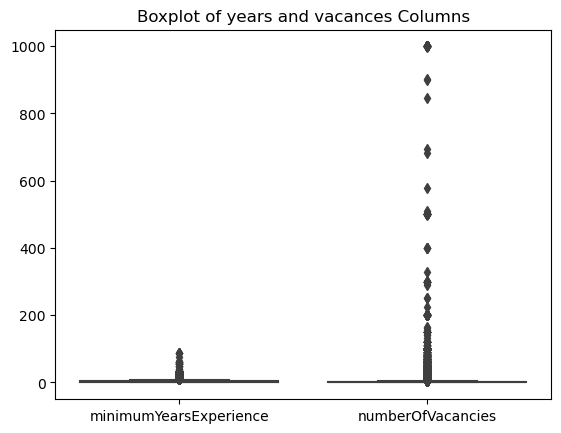

percentile in 25, 50, 75, 90, 95, 99
years of experiences: [ 1.  2.  4.  5.  8. 10.]
number of vacancies: [ 1.  1.  2.  5.  6. 20.]


In [10]:
  
sns.boxplot(df[['minimumYearsExperience','numberOfVacancies']])
plt.title('Boxplot of years and vacances Columns')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

print ('percentile in 25, 50, 75, 90, 95, 99')
print (f'years of experiences: {np.percentile(df["minimumYearsExperience"], [25, 50, 75, 90, 95, 99])}')
print (f'number of vacancies: {np.percentile(df["numberOfVacancies"], [25, 50, 75, 90, 95, 99])}')



### ⭐ Summary after initial profiling

- salary has some outliers, and there are some null values in salary_type, which we will need to clean up.
- minimal years experiencs and number of vacancies have some outliers, which we will need to clean up.
- there are some null values in the dataset:
    * salary_type has 1000+ null values, which we will need to clean up.
    * 3988 rows with 12 columns null, which we will need to drop.
    * 1 column occupation is null

## Section 2: Data Cleaning

### salary clean up

In [11]:
print(df['salary_type'].info())
print(df['salary_type'].describe())


for col in ['average_salary', 'salary_minimum', 'salary_maximum']:
    # Calculate Q1, Q3, and IQR
    q1, q3 = np.percentile(df[col], [25, 75])
    iqr = q3 - q1
    
    # Calculate the theoretical whisker boundaries
    lower_whisker_limit = q1 - (1.5 * iqr)
    upper_whisker_limit = q3 + (1.5 * iqr)
    
    # Actual whiskers end at the last data point within those limits
    actual_lower = df[df[col] >= lower_whisker_limit][col].min()
    actual_upper = df[df[col] <= upper_whisker_limit][col].max()
    
    print(f"{col}: Lower Whisker = {actual_lower:,.0f}, Upper Whisker = {actual_upper:,.0f}")

<class 'pandas.core.series.Series'>
RangeIndex: 1048585 entries, 0 to 1048584
Series name: salary_type
Non-Null Count    Dtype 
--------------    ----- 
1044597 non-null  object
dtypes: object(1)
memory usage: 8.0+ MB
None
count     1044597
unique          1
top       Monthly
freq      1044597
Name: salary_type, dtype: object
average_salary: Lower Whisker = 0, Upper Whisker = 9,400
salary_minimum: Lower Whisker = 0, Upper Whisker = 7,500
salary_maximum: Lower Whisker = 0, Upper Whisker = 11,300


### cheat sheet for handling these landmines:

#### Loading and initial profiling:

In [12]:
# Shape, types, missing values at a glance
print(f"Rows: {df.shape[0]:,}  Columns: {df.shape[1]}")
print("\nNull counts:\n", df.isnull().sum().sort_values(ascending=False).head(10))
print("\nBasic stats:\n", df[['salary_minimum','salary_maximum','average_salary',
                               'minimumYearsExperience','numberOfVacancies']].describe())


Rows: 1,048,585  Columns: 22

Null counts:
 occupationId                    1048585
categories                         3988
metadata_expiryDate                3988
title                              3988
metadata_jobPostId                 3988
metadata_newPostingDate            3988
metadata_originalPostingDate       3988
status_jobStatus                   3988
salary_type                        3988
employmentTypes                    3988
dtype: int64

Basic stats:
        salary_minimum  salary_maximum  average_salary  minimumYearsExperience  \
count    1.048585e+06    1.048585e+06    1.048585e+06            1.048585e+06   
mean     3.815312e+03    5.723578e+03    4.769445e+03            2.779573e+00   
std      3.172182e+03    5.018387e+04    2.547809e+04            2.537049e+00   
min      0.000000e+00    0.000000e+00    0.000000e+00            0.000000e+00   
25%      2.500000e+03    3.300000e+03    2.900000e+03            1.000000e+00   
50%      3.000000e+03    4.500000e+03    3

#### Salary cleaning example


In [13]:
# Remove obvious outliers using the 99th percentile
p99 = np.percentile(df['average_salary'].dropna(), 99)
df_clean = df[(df['average_salary'] > 500) & (df['average_salary'] <= p99)].copy()

# Use NumPy to compute stats on the cleaned array
sal = df_clean['average_salary'].to_numpy()
print(f"Mean: {np.mean(sal):,.0f}  Median: {np.median(sal):,.0f}  Std: {np.std(sal):,.0f}")
print(f"25th pct: {np.percentile(sal, 25):,.0f}  75th pct: {np.percentile(sal, 75):,.0f}")


Mean: 4,551  Median: 3,800  Std: 2,533
25th pct: 2,900  75th pct: 5,500


#### Groupby aggregation — salary by position level:

In [14]:
salary_by_level = (
    df_clean
    .groupby('positionLevels')['average_salary']
    .agg(['mean', 'median', 'count'])
    .rename(columns={'mean': 'avg_salary', 'median': 'median_salary', 'count': 'num_jobs'})
    .sort_values('median_salary', ascending=False)
)
print(salary_by_level)

                    avg_salary  median_salary  num_jobs
positionLevels                                         
Senior Management  9166.091606         8750.0     19644
Middle Management  7017.119383         6300.0     25925
Manager            6605.116159         6000.0    108347
Professional       6647.986773         6000.0    108489
Senior Executive   5586.637209         5000.0     99636
Executive          4119.707783         3750.0    252595
Junior Executive   3380.171451         3150.0    166809
Non-executive      3000.358858         2750.0    129472
Fresh/entry level  2793.007436         2600.0    115659


#### Parsing the `categories` JSON string (one row → first category):

In [15]:
import re

def extract_first_category(cat_str):
    """Extract the first category label from the JSON-like string."""
    if pd.isna(cat_str):
        return np.nan
    match = re.search(r'"category"\s*:\s*"([^"]+)"', str(cat_str))
    return match.group(1) if match else np.nan

df['primary_category'] = df['categories'].apply(extract_first_category)
print(df['primary_category'].value_counts().head(10))


primary_category
Admin / Secretarial                 102719
Information Technology              100142
Engineering                          99675
Accounting / Auditing / Taxation     78648
Building and Construction            74014
Customer Service                     64865
F&B                                  59678
Banking and Finance                  46635
Logistics / Supply Chain             44391
Sales / Retail                       37313
Name: count, dtype: int64


#### Monthly posting trend:

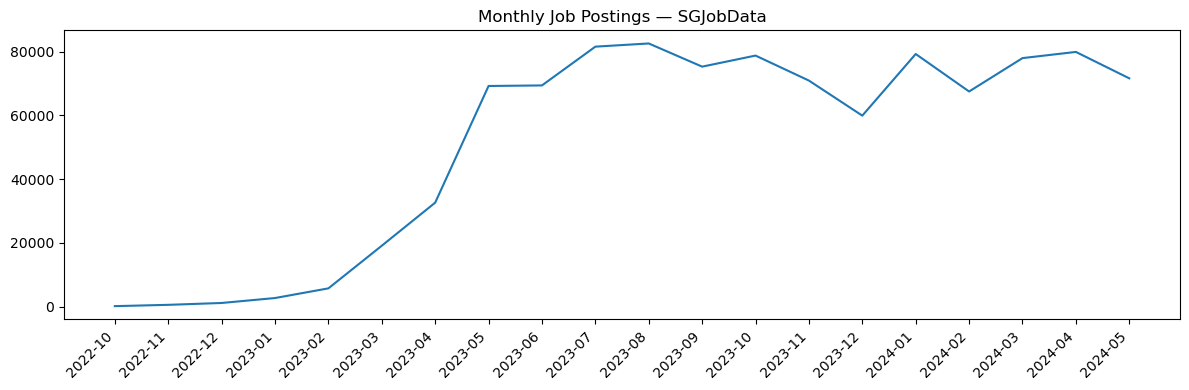

In [16]:
df_clean['year_month'] = df_clean['metadata_originalPostingDate'].dt.to_period('M')
monthly = df_clean.groupby('year_month').size().reset_index(name='postings')

plt.figure(figsize=(12, 4))
plt.plot(monthly['year_month'].astype(str), monthly['postings'])
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Job Postings — SGJobData')
plt.tight_layout()
plt.show()


#### Filtering out recruitment agencies (rough heuristic):

In [17]:
agency_keywords = ['RECRUIT', 'HR ADVISORY', 'MANPOWER', 'STAFFING', 'CONSULT', 'TALENT']
pattern = '|'.join(agency_keywords)

direct_only = df_clean[
    (~df_clean['postedCompany_name'].str.upper().str.contains(pattern, na=False)) &
    (df_clean['metadata_isPostedOnBehalf'] == False)
]

direct_only

,categories,employmentTypes,metadata_expiryDate,metadata_isPostedOnBehalf,metadata_jobPostId,metadata_newPostingDate,metadata_originalPostingDate,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,...,positionLevels,postedCompany_name,salary_maximum,salary_minimum,salary_type,status_id,status_jobStatus,title,average_salary,year_month
0,"[{""id"":13,""category"":""Environment / Health""},{...",Permanent,2023-05-08,False,MCF-2023-0252866,2023-04-08,2023-03-30,2,5,151,...,Executive,WORKSTONE PTE. LTD.,2800,2000,Monthly,0,Closed,Food Technologist - Clementi | Entry Level | U...,2400.0,2023-03
2,"[{""id"":33,""category"":""Repair and Maintenance""}]",Full Time,2023-04-22,False,MCF-2023-0273994,2023-04-08,2023-04-08,0,7,99,...,Senior Executive,PU TIEN SERVICES PTE. LTD.,4600,3800,Monthly,0,Closed,Senior Technician,4200.0,2023-04
4,"[{""id"":2,""category"":""Admin / Secretarial""}]",Full Time,2023-05-08,False,MCF-2023-0273976,2023-04-08,2023-04-08,0,3,99,...,Non-executive,EATZ CATERING SERVICES PTE. LTD.,3400,2400,Monthly,0,Closed,Sales / Admin Cordinator,2900.0,2023-04
7,"[{""id"":37,""category"":""Security and Investigati...",Permanent,2023-05-08,False,MCF-2023-0273993,2023-04-08,2023-04-08,0,9,137,...,Senior Executive,TRITON AI PTE. LTD.,7000,6500,Monthly,0,Closed,IT Security Engineer (Maritime/ Cloud Security),6750.0,2023-04
8,"[{""id"":1,""category"":""Accounting / Auditing / T...",Permanent,2023-05-12,False,MCF-2023-0261996,2023-04-12,2023-04-04,2,5,82,...,Manager,WORKSTONE PTE. LTD.,5500,3000,Monthly,0,Closed,Assistant Sales Manager (Hunter Role)- Up to $...,4250.0,2023-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048542,"[{""id"":21,""category"":""Information Technology""}]",Contract,2024-06-12,False,MCF-2024-0783884,2024-05-29,2024-05-29,0,1,1,...,Professional,OPTIMUM SOLUTIONS (SINGAPORE) PTE LTD,9000,5500,Monthly,0,Open,Senior Middleware Consultant,7250.0,2024-05
1048544,"[{""id"":41,""category"":""Others""}]",Full Time,2024-06-28,False,MCF-2024-0783901,2024-05-29,2024-05-29,0,0,4,...,Non-executive,OVERSEAS FAMILY SCHOOL LIMITED,2800,2500,Monthly,0,Open,SECURITY OFFICER,2650.0,2024-05
1048546,"[{""id"":3,""category"":""Advertising / Media""},{""i...",Contract,2024-06-28,False,MCF-2024-0783887,2024-05-29,2024-05-29,0,1,4,...,Manager,PICO ART INTERNATIONAL PTE. LTD.,7000,6000,Monthly,0,Open,Sales & Sponsorship Manager,6500.0,2024-05
1048555,"[{""id"":13,""category"":""Environment / Health""}]",Full Time,2024-06-28,False,MCF-2024-0783897,2024-05-29,2024-05-29,0,1,4,...,Manager,SPIRAX SARCO PRIVATE LIMITED,10000,8000,Monthly,0,Open,Environmental Health and Safety Manager (SEA),9000.0,2024-05


#### Correlation heatmap:


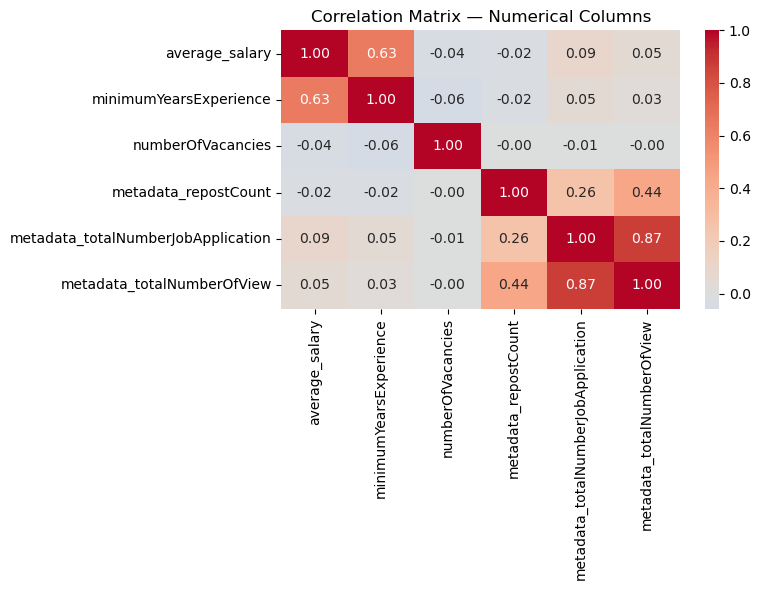

In [18]:
num_cols = ['average_salary', 'minimumYearsExperience', 'numberOfVacancies',
            'metadata_repostCount', 'metadata_totalNumberJobApplication',
            'metadata_totalNumberOfView']
corr = df_clean[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Numerical Columns')
plt.tight_layout()
plt.show()


#### Boxplot for outlier inspection:


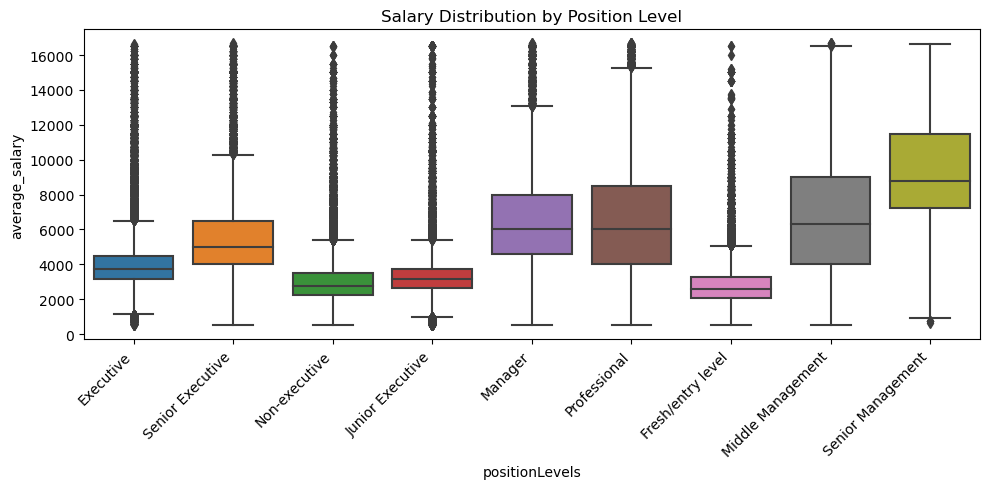

In [19]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x='positionLevels', y='average_salary')
plt.xticks(rotation=45, ha='right')
plt.title('Salary Distribution by Position Level')
plt.tight_layout()
plt.show()


### ❗ TEAM INPUT ❗ Answer these six together as a team. 
- One code block each. 
- Capture your outputs as visible notebook cells — you may refer to them in your presentation.

#### 1. What is the shape of the DataFrame, the date range of metadata_originalPostingDate, and how many unique job post IDs are there?


In [20]:
# General statistics and range
shape = df.shape
date_min = df['metadata_originalPostingDate'].min()
date_max = df['metadata_originalPostingDate'].max()
unique_ids = df['metadata_jobPostId'].nunique()

print(f"DataFrame Shape: {shape}")
print(f"Date Range: {date_min} to {date_max}")
print(f"Unique Job IDs: {unique_ids}")

DataFrame Shape: (1048585, 23)
Date Range: 2022-10-03 00:00:00 to 2024-05-29 00:00:00
Unique Job IDs: 1044597


#### 2. What are the top 10 most common primary_category values, and what percentage of all jobs does each represent? (Use .value_counts(normalize=True))


In [21]:
# Frequency and percentage of top categories
top_10_counts = df['primary_category'].value_counts().head(10)
top_10_pct = df['primary_category'].value_counts(normalize=True).head(10) * 100

summary_categories = pd.DataFrame({
    'Count': top_10_counts,
    'Percentage (%)': top_10_pct.round(2)
})
print(summary_categories)

                                   Count  Percentage (%)
primary_category                                        
Admin / Secretarial               102719            9.83
Information Technology            100142            9.59
Engineering                        99675            9.54
Accounting / Auditing / Taxation   78648            7.53
Building and Construction          74014            7.09
Customer Service                   64865            6.21
F&B                                59678            5.71
Banking and Finance                46635            4.46
Logistics / Supply Chain           44391            4.25
Sales / Retail                     37313            3.57


#### 3. After removing salary outliers, what is the median average_salary broken down by positionLevels? Sort from highest to lowest.


In [22]:
# Filtering outliers using IQR and grouping
Q1 = df['average_salary'].quantile(0.25)
Q3 = df['average_salary'].quantile(0.75)
IQR = Q3 - Q1
filtered_df = df[(df['average_salary'] >= (Q1 - 1.5 * IQR)) & 
                 (df['average_salary'] <= (Q3 + 1.5 * IQR))]

median_salary_levels = filtered_df.groupby('positionLevels')['average_salary'].median().sort_values(ascending=False)
print(median_salary_levels)

positionLevels
Senior Management    7500.0
Manager              5750.0
Professional         5150.0
Senior Executive     5000.0
Middle Management    4750.0
Executive            3750.0
Junior Executive     3150.0
Non-executive        2700.0
Fresh/entry level    2550.0
Name: average_salary, dtype: float64


#### 4. Which 5 columns have the most missing values? What percentage of rows are null in each?


In [23]:
# Identifying columns with the highest null counts
missing_values = df.isnull().sum().sort_values(ascending=False).head(5)
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False).head(5)

missing_summary = pd.DataFrame({
    'Missing Count': missing_values,
    'Percentage Null (%)': missing_pct.round(2)
})
print(missing_summary)

                  Missing Count  Percentage Null (%)
occupationId            1048585               100.00
categories                 3988                 0.38
employmentTypes            3988                 0.38
title                      3988                 0.38
status_jobStatus           3988                 0.38


#### 5. What is the distribution of minimumYearsExperience? Plot a histogram. Where does the bulk of demand sit?


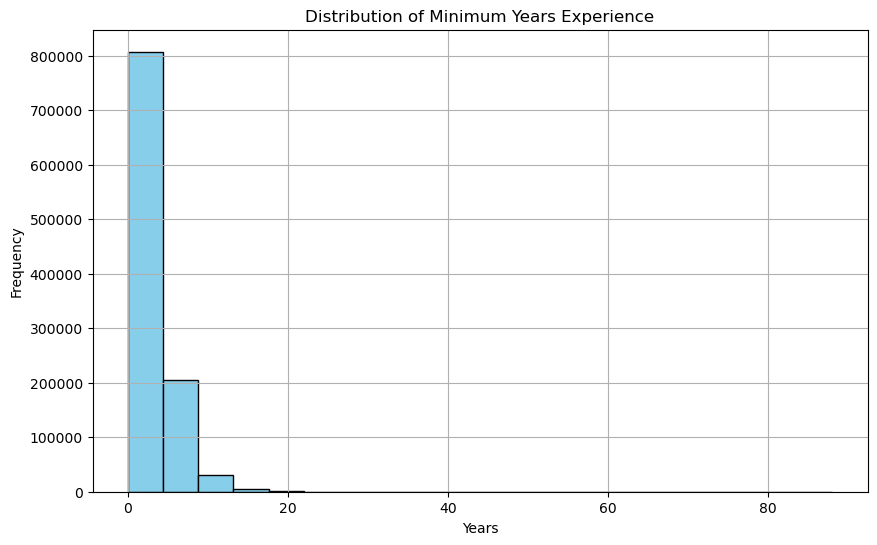

The bulk of demand sits at: 1 years of experience.


In [24]:
# Distribution of minimum years of experience
plt.figure(figsize=(10, 6))
df['minimumYearsExperience'].hist(bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Minimum Years Experience')
plt.xlabel('Years')
plt.ylabel('Frequency')
plt.show()

bulk_demand = df['minimumYearsExperience'].mode()[0]
print(f"The bulk of demand sits at: {bulk_demand} years of experience.")

#### 6. Compute the correlation between average_salary, minimumYearsExperience, metadata_repostCount, and metadata_totalNumberJobApplication. Which pair has the strongest relationship?


In [25]:
# Computing correlation for numerical features
cols = ['average_salary', 'minimumYearsExperience', 'metadata_repostCount', 'metadata_totalNumberJobApplication']
corr_matrix = df[cols].corr()

# Find the strongest relationship (excluding self-correlation)
strongest_pair = corr_matrix.unstack().sort_values(ascending=False).drop_duplicates()
top_corr = strongest_pair.index[1]

print("Correlation Matrix:")
print(corr_matrix)
print(f"\nStrongest Relationship: {top_corr}")

Correlation Matrix:
                                    average_salary  minimumYearsExperience  \
average_salary                            1.000000                0.115350   
minimumYearsExperience                    0.115350                1.000000   
metadata_repostCount                      0.003684               -0.021168   
metadata_totalNumberJobApplication        0.180189                0.070024   

                                    metadata_repostCount  \
average_salary                                  0.003684   
minimumYearsExperience                         -0.021168   
metadata_repostCount                            1.000000   
metadata_totalNumberJobApplication              0.250941   

                                    metadata_totalNumberJobApplication  
average_salary                                                0.180189  
minimumYearsExperience                                        0.070024  
metadata_repostCount                                          0.25094

## Section 3: Data Refinement for Business Questions


***

### ❗ TEAM INPUT ❗ Assumptions made duringData Cleaning
`li zhongyi, Lin Minghui (Reeve), Mao Jianwen (Tony), Nainar Mohamed (Nainar), Yang Shicong (Shicong)`

**This section outlines the data cleaning and processing rules applied to this notebook.**

1. Salary Outliers: 

2. Missing Data: 

3. <>> 

4. <>

5. <>

***


### data